In [1]:
# FIFA World Cup 2026 Player Performance - Data Cleaning & Visualization Project

# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
# Step 2: Load dataset
df = pd.read_csv("fifa_world_cup_2026_player_performance.csv")

In [3]:
#Step 3: Overview
print(df.head())

  player_id       player_name  age nationality   team  jersey_number  \
0    P00055        Rodri Fati   26     Spanish  Spain              3   
1    P00070   Ansu Le Normand   19     Spanish  Spain             18   
2    P00066        Gavi Ramos   18     Spanish  Spain             14   
3    P00073     Pedro Cubarsi   20     Spanish  Spain             21   
4    P00059  Alvaro Oyarzabal   23     Spanish  Spain              7   

     position  height_cm  weight_kg preferred_foot  ... possession_impact  \
0  Goalkeeper        195         75           Left  ...               1.1   
1  Midfielder        178         75          Right  ...               3.5   
2  Midfielder        177         72           Left  ...              15.3   
3     Forward        182         74          Right  ...               1.2   
4    Defender        191         81           Left  ...               6.2   

   pressure_resistance creativity_score consistency_score  \
0                 44.2             55.9    

In [8]:
print(df[['player_id', 'player_name', 'age', 'nationality']].head())

  player_id       player_name  age nationality
0    P00055        Rodri Fati   26     Spanish
1    P00070   Ansu Le Normand   19     Spanish
2    P00066        Gavi Ramos   18     Spanish
3    P00073     Pedro Cubarsi   20     Spanish
4    P00059  Alvaro Oyarzabal   23     Spanish


In [11]:
pd.set_option('display.max_columns', 10)   # show only 10 columns
print(df.head())

  player_id       player_name  age nationality   team  ...  \
0    P00055        Rodri Fati   26     Spanish  Spain  ...   
1    P00070   Ansu Le Normand   19     Spanish  Spain  ...   
2    P00066        Gavi Ramos   18     Spanish  Spain  ...   
3    P00073     Pedro Cubarsi   20     Spanish  Spain  ...   
4    P00059  Alvaro Oyarzabal   23     Spanish  Spain  ...   

   total_goals_tournament total_assists_tournament  total_minutes_tournament  \
0                       0                        0                       242   
1                       0                        3                       342   
2                       1                        1                       245   
3                       5                        3                       422   
4                       0                        0                       440   

   player_of_match_awards tournament_rating  
0                       0               5.8  
1                       0               5.5  
2       

In [12]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 54600 non-null  object 
 1   player_name               54600 non-null  object 
 2   age                       54600 non-null  int64  
 3   nationality               54600 non-null  object 
 4   team                      54600 non-null  object 
 5   jersey_number             54600 non-null  int64  
 6   position                  54600 non-null  object 
 7   height_cm                 54600 non-null  int64  
 8   weight_kg                 54600 non-null  int64  
 9   preferred_foot            54600 non-null  object 
 10  club_name                 54600 non-null  object 
 11  market_value_eur          54600 non-null  int64  
 12  match_id                  54600 non-null  object 
 13  match_date                54600 non-null  object 
 14  stadiu

In [14]:
print(df.describe())

                age  jersey_number     height_cm     weight_kg  \
count  54600.000000   54600.000000  54600.000000  54600.000000   
mean      26.296484      13.500000    181.654341     75.754853   
std        4.067519       7.500069      6.277792      3.951481   
min       17.000000       1.000000    163.000000     65.000000   
25%       23.000000       7.000000    177.000000     73.000000   
50%       26.000000      13.500000    182.000000     76.000000   
75%       29.000000      20.000000    186.000000     78.000000   
max       39.000000      26.000000    200.000000     87.000000   

       market_value_eur  ...  total_goals_tournament  \
count      5.460000e+04  ...            54600.000000   
mean       2.008445e+07  ...                0.643993   
std        2.718866e+07  ...                1.093781   
min        5.288220e+05  ...                0.000000   
25%        4.444778e+06  ...                0.000000   
50%        1.027111e+07  ...                0.000000   
75%        2.

In [20]:
# Step 4: Handle missing values
# Drop rows with too many missing values
df = df.dropna(thresh=len(df.columns) - 3)

In [21]:
# Fill numeric columns with median
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [22]:
# Fill categorical columns with mode
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [23]:
# Step 5: Handle duplicates
df = df.drop_duplicates()

In [26]:
# Step 6: Handle outliers (example: Goals column using IQR)
Q1 = df['total_goals_tournament'].quantile(0.25)
Q3 = df['total_goals_tournament'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['total_goals_tournament'] < (Q1 - 1.5 * IQR)) | (df['total_goals_tournament'] > (Q3 + 1.5 * IQR)))]

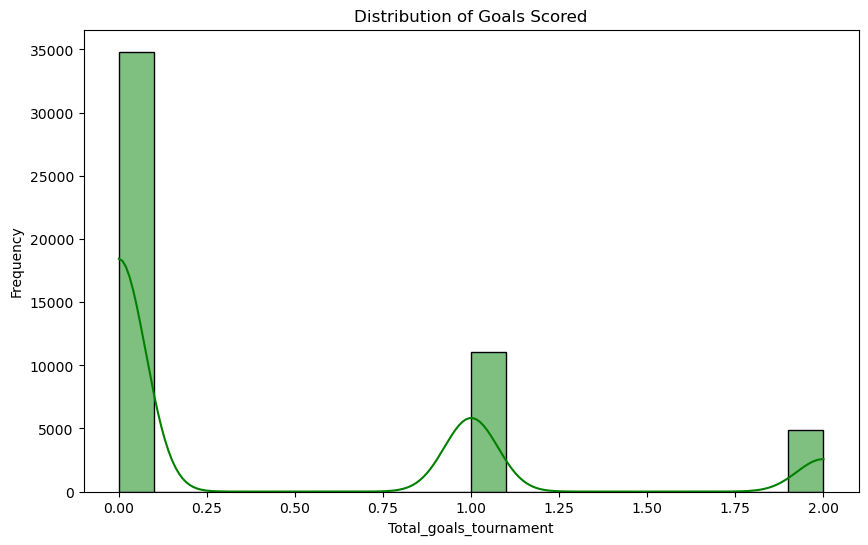

In [27]:
# Step 7: Visualization

# Distribution of Goals
plt.figure(figsize=(10,6))
sns.histplot(df['total_goals_tournament'], bins=20, kde=True, color="green") 
plt.title("Distribution of Goals Scored")
plt.xlabel("Total_goals_tournament") # No. of goals scored  in goal 0, goal 1, goal 2
plt.ylabel("Frequency") # No. of players scored in each bins
plt.show()

C:\Users\pc\AppData\Local\Temp\ipykernel_14244\507220124.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scorers.values, y=top_scorers.index, palette="viridis")


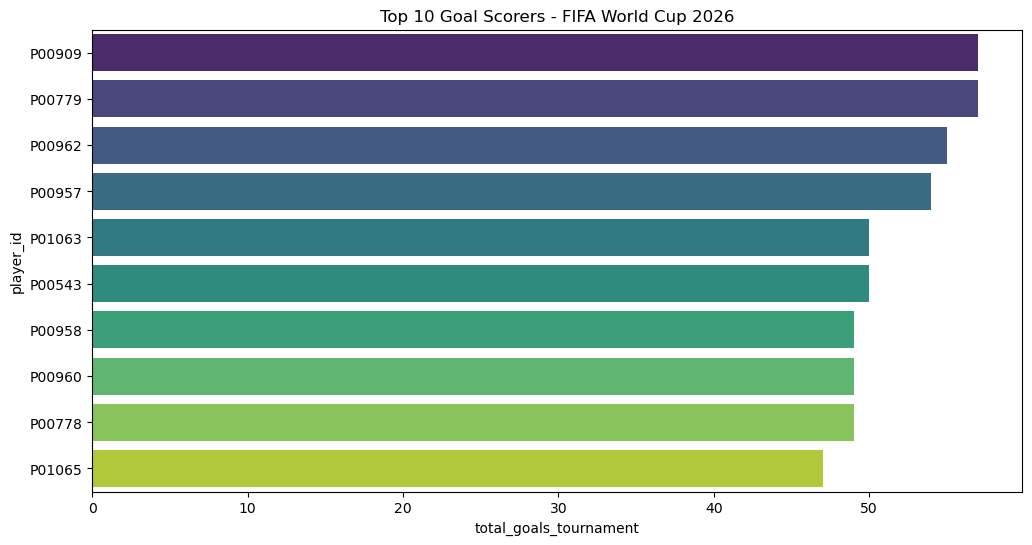

In [29]:
# Top 10 Goal Scorers
top_scorers = df.groupby("player_id")['total_goals_tournament'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_scorers.values, y=top_scorers.index, palette="viridis")
plt.title("Top 10 Goal Scorers - FIFA World Cup 2026")
plt.xlabel("total_goals_tournament") # How many goals players scored.
plt.ylabel("player_id") # Each bars correspond to player_id.
plt.show()

C:\Users\pc\AppData\Local\Temp\ipykernel_14244\1360236719.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="position", y="assists", data=df, palette="Set2")


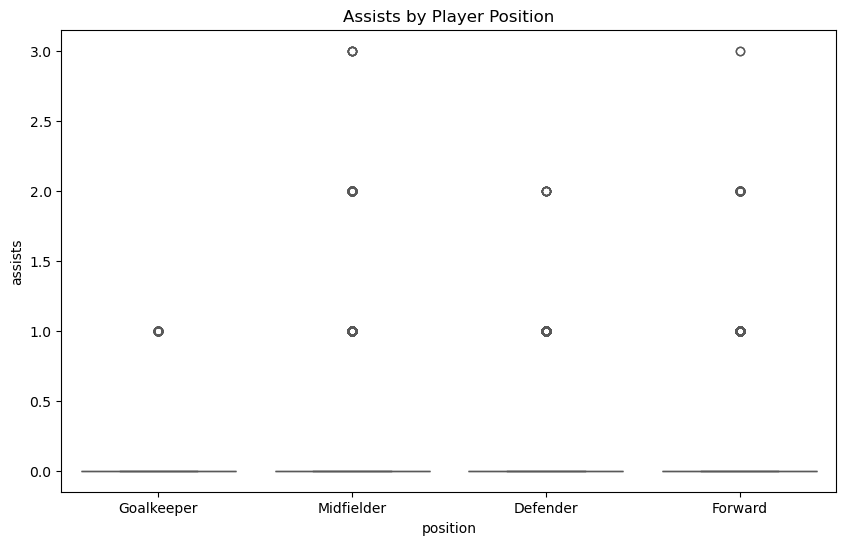

In [32]:
# Assists by Position
plt.figure(figsize=(10,6))
sns.boxplot(x="position", y="assists", data=df, palette="Set2")
plt.title("Assists by Player Position")
plt.show()

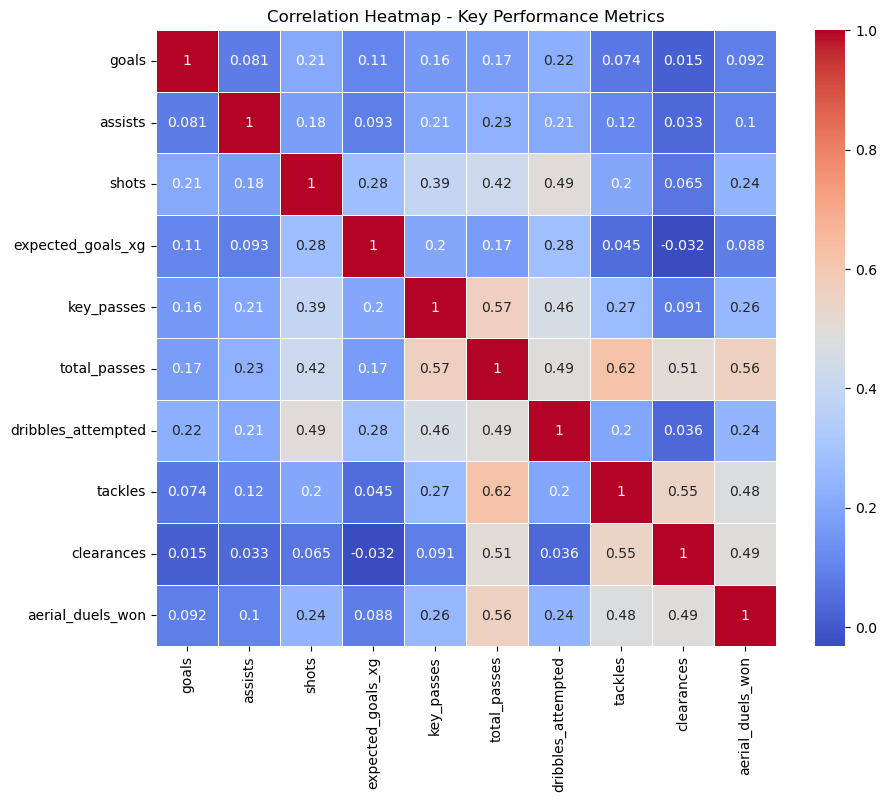

In [34]:
# Selecting only performance-related columns 
performance_cols = ['goals', 'assists', 'shots', 'expected_goals_xg',
                    'key_passes', 'total_passes', 'dribbles_attempted',
                    'tackles', 'clearances', 'aerial_duels_won']

plt.figure(figsize=(10,8))
sns.heatmap(df[performance_cols].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap - Key Performance Metrics")
plt.show()

In [35]:
# Step 8: Save cleaned dataset
df.to_csv("fifa2026_cleaned.csv", index=False)